<a href="https://colab.research.google.com/github/ankq1q2/customer_data_analysis/blob/main/4222124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

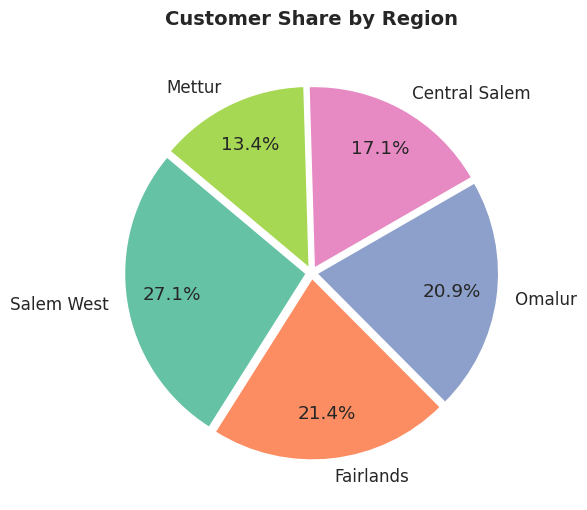


--------------------------------------------------------------------------------



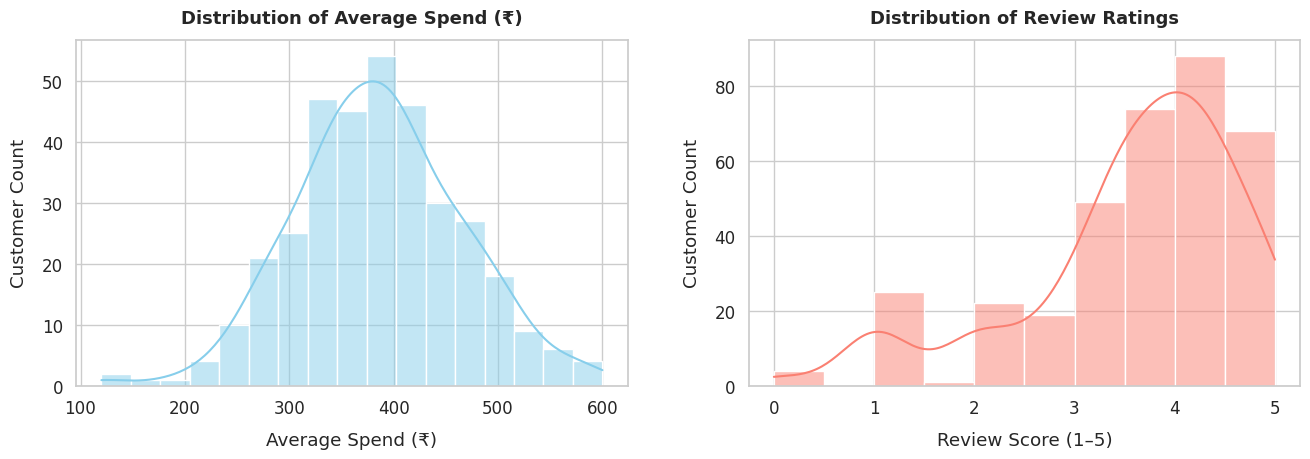


--------------------------------------------------------------------------------



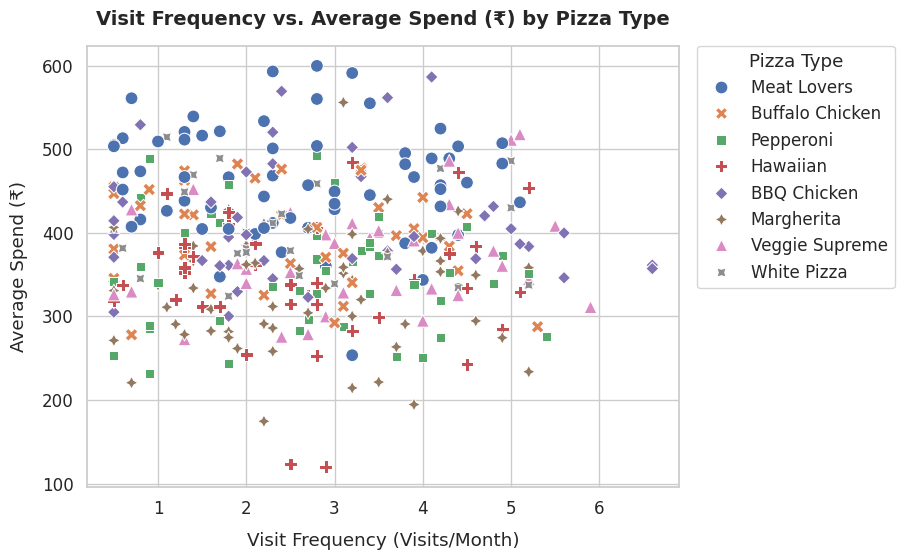


--------------------------------------------------------------------------------



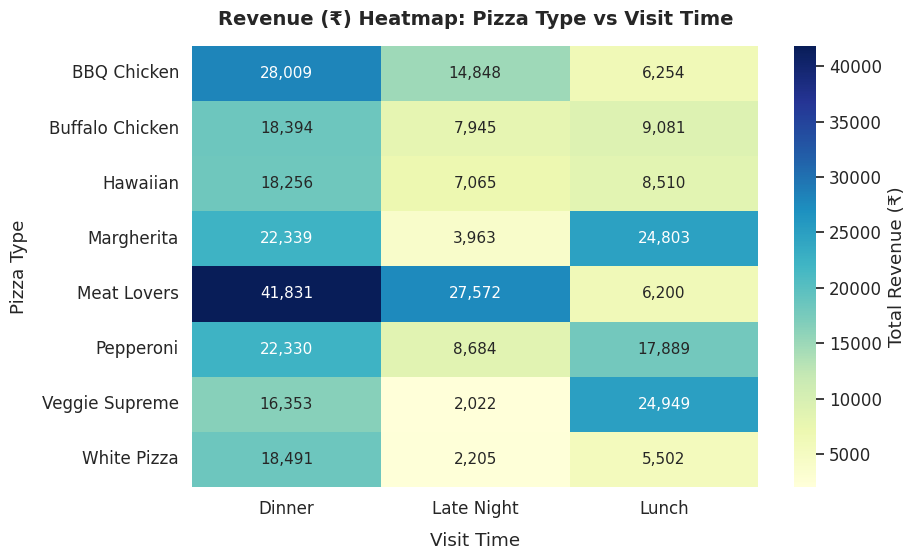


--------------------------------------------------------------------------------



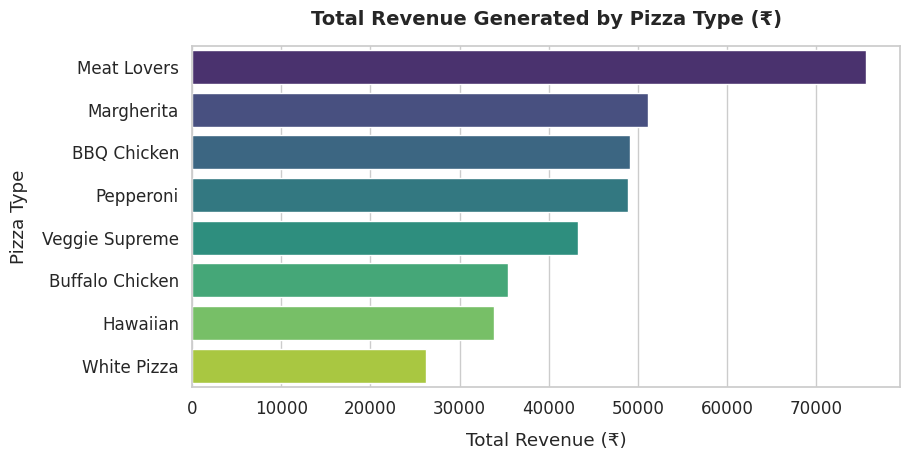


--------------------------------------------------------------------------------



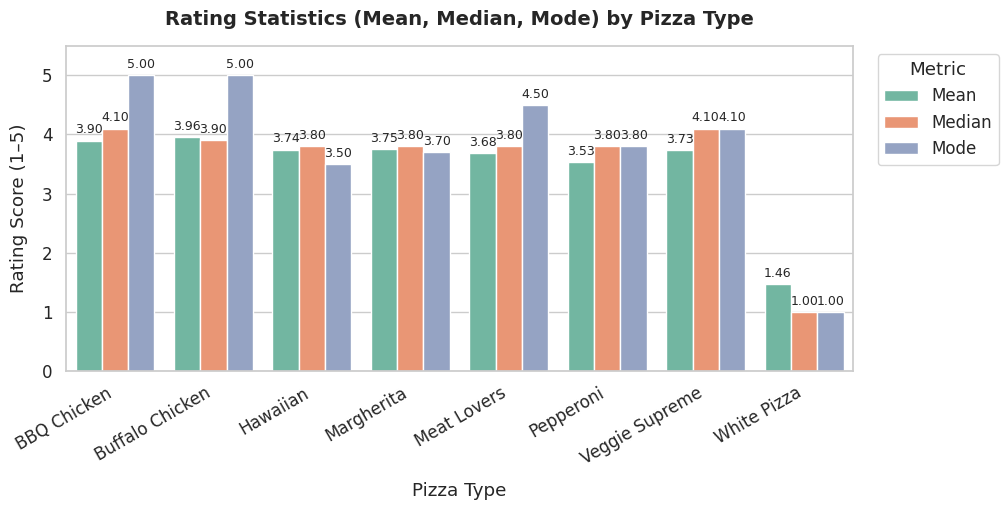


DATASET SUMMARY INSIGHTS (IN INR)
Most Profitable Pizza: Meat Lovers (₹75,602.18)
Worst / Lowest Revenue Pizza: White Pizza (₹26,197.69)
Peak Time Zone by Sales Revenue: Dinner (₹186,001.66)
Highest Revenue Combination: Meat Lovers during Dinner (₹41,830.60)

RATING STATISTICS PER PIZZA TYPE (MEAN, MEDIAN, MODE)
      PizzaType     Mean  Median  Mode
    BBQ Chicken 3.895238     4.1   5.0
Buffalo Chicken 3.956757     3.9   5.0
       Hawaiian 3.744737     3.8   3.5
     Margherita 3.753448     3.8   3.7
    Meat Lovers 3.682812     3.8   4.5
      Pepperoni 3.532000     3.8   3.8
 Veggie Supreme 3.734286     4.1   4.1
    White Pizza 1.461538     1.0   1.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'eastern_coast_pizza_customers_2.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
df['Region'] = df['Region'].astype(str).str.title()
df['TotalRevenue'] = df['AvgSpend'] * df['VisitFrequency']

sns.set_theme(style="whitegrid", font_scale=1.1)

# VISUALIZATION 1: Pie Chart
plt.figure(figsize=(8, 6))
region_counts = df['Region'].value_counts()
plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2"),
    pctdistance=0.75,
    explode=[0.03] * len(region_counts),
)
plt.title("Customer Share by Region", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(pad=3.0)
plt.show()

print("\n" + "-" * 80 + "\n")

# VISUALIZATION 2: Histograms (Average Spend & Review Ratings)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(df['AvgSpend'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(
    "Distribution of Average Spend (₹)",
    fontsize=13,
    fontweight='bold',
    pad=12,
)
axes[0].set_xlabel("Average Spend (₹)", labelpad=10)
axes[0].set_ylabel("Customer Count", labelpad=10)

sns.histplot(df['Review'], kde=True, ax=axes[1], color='salmon', bins=10)
axes[1].set_title(
    "Distribution of Review Ratings", fontsize=13, fontweight='bold', pad=12
)
axes[1].set_xlabel("Review Score (1–5)", labelpad=10)
axes[1].set_ylabel("Customer Count", labelpad=10)

plt.subplots_adjust(wspace=0.35)
plt.tight_layout(pad=3.0)
plt.show()

print("\n" + "-" * 80 + "\n")

# VISUALIZATION 3: Scatter Plot (Visit Frequency vs Avg Spend)
plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=df,
    x='VisitFrequency',
    y='AvgSpend',
    hue='PizzaType',
    style='PizzaType',
    s=85,
)
plt.title(
    "Visit Frequency vs. Average Spend (₹) by Pizza Type",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Visit Frequency (Visits/Month)", labelpad=10)
plt.ylabel("Average Spend (₹)", labelpad=10)
plt.legend(
    bbox_to_anchor=(1.03, 1),
    loc='upper left',
    title="Pizza Type",
    borderaxespad=0,
)
plt.tight_layout(pad=3.0)
plt.show()

print("\n" + "-" * 80 + "\n")

# VISUALIZATION 4: Heatmap (Revenue: Pizza Type vs Visit Time)
pivot_revenue = df.pivot_table(
    index='PizzaType', columns='VisitTime', values='TotalRevenue', aggfunc='sum'
)
plt.figure(figsize=(10, 6.5))
sns.heatmap(
    pivot_revenue,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Total Revenue (₹)'},
    annot_kws={"size": 11},
)
plt.title(
    "Revenue (₹) Heatmap: Pizza Type vs Visit Time",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.ylabel("Pizza Type", labelpad=10)
plt.xlabel("Visit Time", labelpad=10)
plt.tight_layout(pad=3.0)
plt.show()

print("\n" + "-" * 80 + "\n")

# VISUALIZATION 5: Bar Chart (Total Revenue by Pizza Type) - FIXED
pizza_rev = (
    df.groupby('PizzaType')['TotalRevenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=pizza_rev,
    x='TotalRevenue',
    y='PizzaType',
    hue='PizzaType',
    palette='viridis',
    legend=False,
)
plt.title(
    "Total Revenue Generated by Pizza Type (₹)",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Total Revenue (₹)", labelpad=10)
plt.ylabel("Pizza Type", labelpad=10)
plt.tight_layout(pad=3.0)
plt.show()

print("\n" + "-" * 80 + "\n")


# VISUALIZATION 6: Rating Statistics (Mean, Median, Mode) by Pizza Type
def get_mode(series):
  m = series.mode()
  return m.iloc[0] if not m.empty else np.nan


rating_stats = (
    df.groupby('PizzaType')['Review']
    .agg(Mean='mean', Median='median', Mode=get_mode)
    .reset_index()
)

rating_stats_melted = rating_stats.melt(
    id_vars='PizzaType', var_name='Metric', value_name='Score'
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=rating_stats_melted,
    x='PizzaType',
    y='Score',
    hue='Metric',
    palette='Set2',
)
plt.title(
    "Rating Statistics (Mean, Median, Mode) by Pizza Type",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Pizza Type", labelpad=10)
plt.ylabel("Rating Score (1–5)", labelpad=10)
plt.ylim(0, 5.5)

for p in ax.patches:
  height = p.get_height()
  if not np.isnan(height) and height > 0:
    ax.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points',
    )

plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(pad=3.0)
plt.show()

# SUMMARY PRINT OUT
print("\n" + "=" * 60)
print("DATASET SUMMARY INSIGHTS (IN INR)")
print("=" * 60)

most_profitable = pizza_rev.iloc[0]
least_profitable = pizza_rev.iloc[-1]
print(
    f"Most Profitable Pizza: {most_profitable['PizzaType']}"
    f" (₹{most_profitable['TotalRevenue']:,.2f})"
)
print(
    f"Worst / Lowest Revenue Pizza: {least_profitable['PizzaType']}"
    f" (₹{least_profitable['TotalRevenue']:,.2f})"
)

time_rev = (
    df.groupby('VisitTime')['TotalRevenue'].sum().sort_values(ascending=False)
)
print(
    f"Peak Time Zone by Sales Revenue: {time_rev.index[0]}"
    f" (₹{time_rev.iloc[0]:,.2f})"
)

comb_rev = (
    df.groupby(['VisitTime', 'PizzaType'])['TotalRevenue']
    .sum()
    .reset_index()
    .sort_values(by='TotalRevenue', ascending=False)
    .iloc[0]
)
print(
    f"Highest Revenue Combination: {comb_rev['PizzaType']} during"
    f" {comb_rev['VisitTime']} (₹{comb_rev['TotalRevenue']:,.2f})"
)

print("\n" + "=" * 60)
print("RATING STATISTICS PER PIZZA TYPE (MEAN, MEDIAN, MODE)")
print("=" * 60)
print(rating_stats.to_string(index=False))